# Kiểm định chất lượng DurianLDD

Notebook này điều phối bước phân tích khám phá và kiểm định chất lượng của DurianLDD. Phạm vi dừng ở dữ liệu chính. Split mới chưa được tạo ở bước này.

Chạy lại toàn bộ kiểm định:

```text
python -m src.data.quality_audit --dataset-root datasets/durian-ldd --output-dir reports/data_quality
```


In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "reports" / "data_quality" / "summary.json").exists():
    ROOT = ROOT.parent
REPORT_DIR = ROOT / "reports" / "data_quality"
summary = json.loads((REPORT_DIR / "summary.json").read_text(encoding="utf-8"))
inventory = pd.read_csv(REPORT_DIR / "tables" / "image_inventory.csv")
decision = (
    "DurianLDD đủ điều kiện tiếp tục thực nghiệm."
    if summary["eligible"]
    else "DurianLDD chưa đủ điều kiện tiếp tục thực nghiệm."
)
display(Markdown(f"**{decision}**"))
for item in summary["conditions"]:
    display(Markdown(f"- {item}"))


**DurianLDD đủ điều kiện tiếp tục thực nghiệm.**

- Split có sẵn chứa cặp gần trùng xuyên train, validation hoặc test. Không dùng split này làm split đã khóa. Bước chia tập phải giữ mỗi nhóm gần trùng trong một tập.

- Mọi ảnh đọc được cùng một kích thước. Thống kê độ phân giải mô tả bản phát hành, không mô tả ảnh lúc chụp.

- Không có thời điểm chụp trong EXIF. Lần kiểm tra này không truy được cùng một phiên chụp khi hai ảnh đã khác nhau rõ.

## Phân bố lớp và split có sẵn


,class_name,images
0,ALGAL_LEAF_SPOT,733
1,ALLOCARIDARA_ATTACK,913
2,HEALTHY_LEAF,976
3,LEAF_BLIGHT,937
4,PHOMOPSIS_LEAF_SPOT,878


split,test,train,val
class_name,,,
ALGAL_LEAF_SPOT,147,513,73
ALLOCARIDARA_ATTACK,183,639,91
HEALTHY_LEAF,196,683,97
LEAF_BLIGHT,188,655,94
PHOMOPSIS_LEAF_SPOT,176,614,88


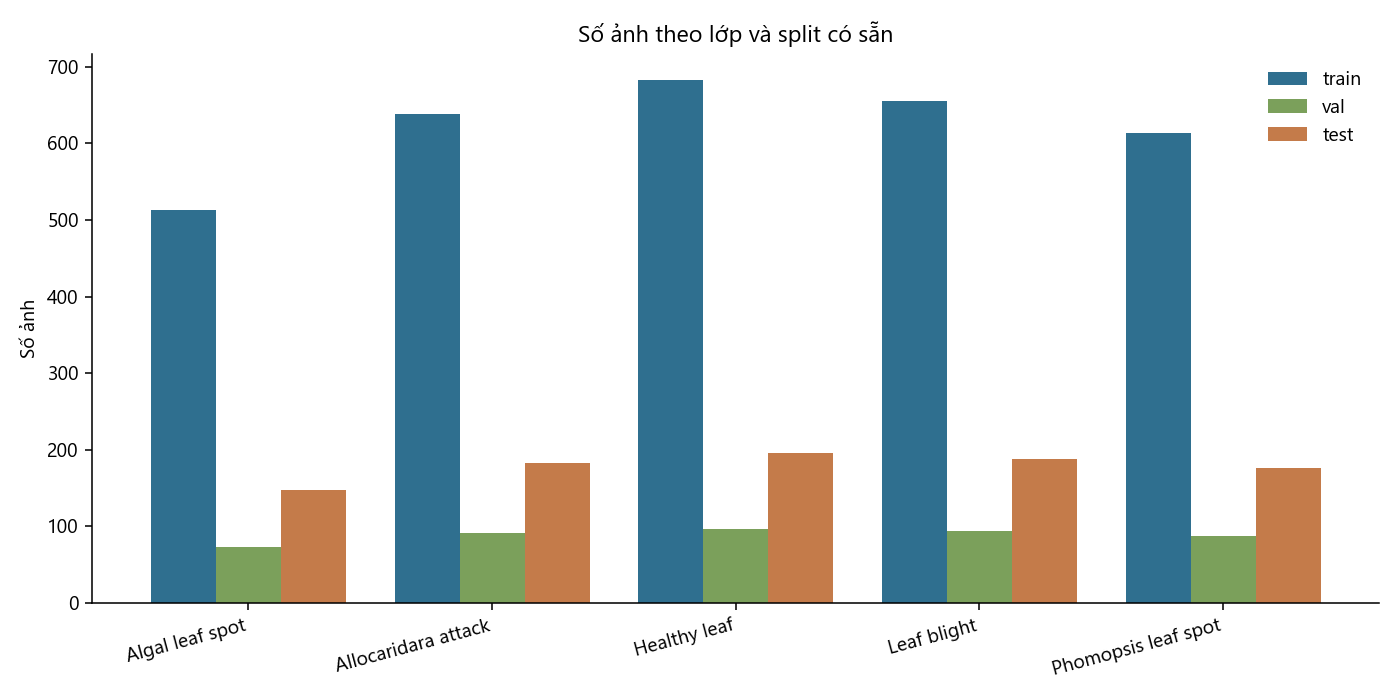

In [2]:
readable = inventory[inventory["readable"] == True]
class_counts = readable.groupby("class_name").size().rename("images").reset_index()
split_counts = pd.crosstab(readable["class_name"], readable["split"])
display(class_counts)
display(split_counts)
display(Image(filename=str(REPORT_DIR / "figures" / "class_distribution.png")))


## Kích thước và chất lượng ảnh

Bản phát hành đã được đưa về 224x224. Các chỉ số chất lượng được đo trên bản này.


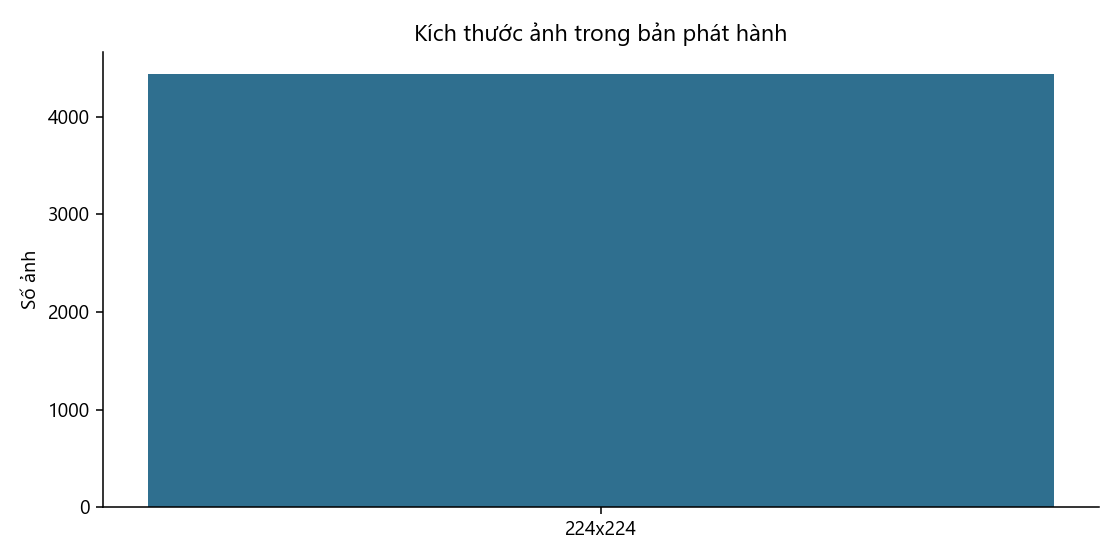

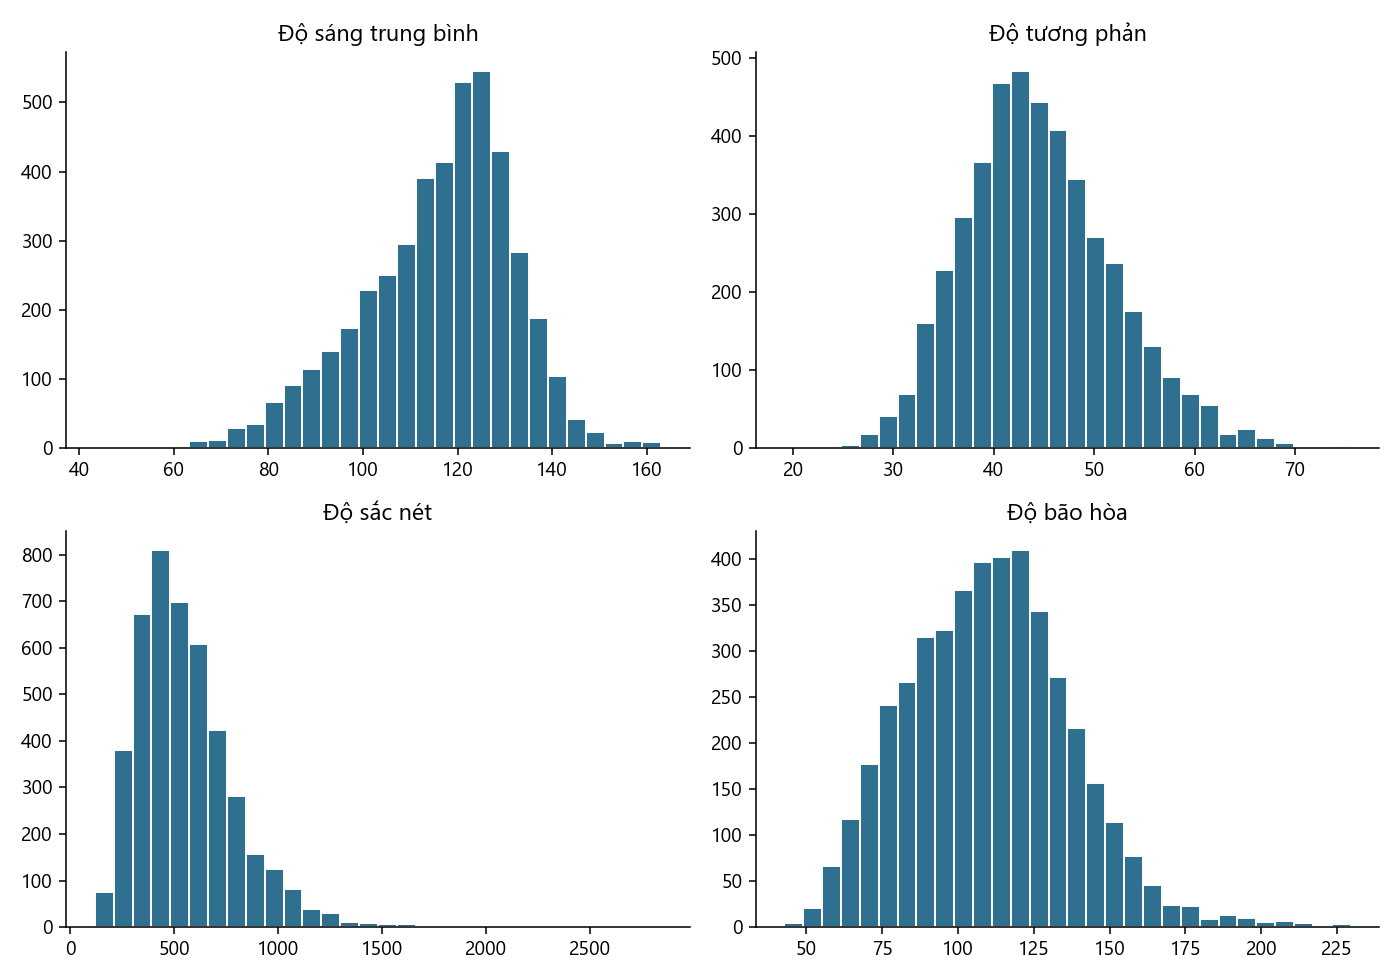

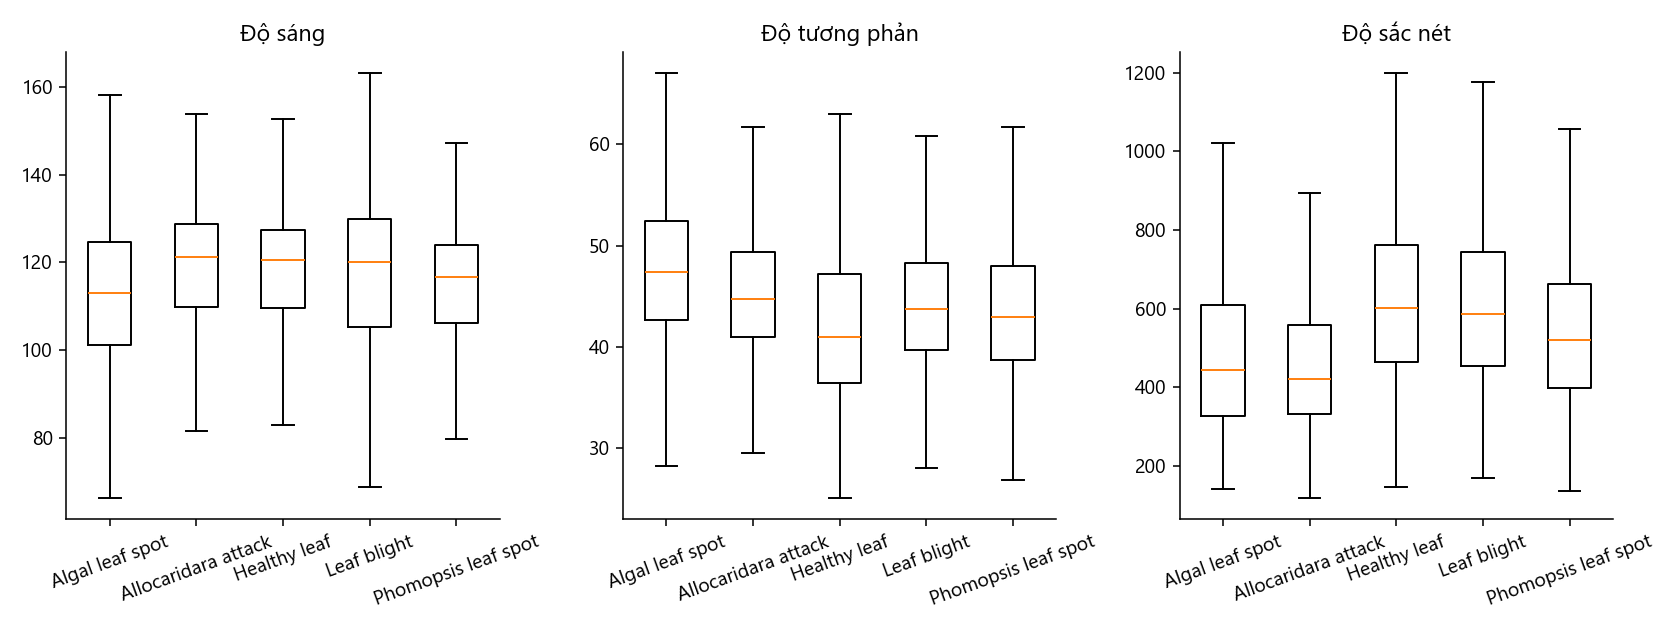

,class_name,images,brightness_median,contrast_median,sharpness_median,saturation_median
0,ALGAL_LEAF_SPOT,733,112.938636,47.426368,444.064548,95.974231
1,ALLOCARIDARA_ATTACK,913,121.137994,44.719251,420.537942,104.196110
2,HEALTHY_LEAF,976,120.503697,40.974304,601.291737,120.355987
3,LEAF_BLIGHT,937,120.068579,43.719292,586.534529,101.231565
4,PHOMOPSIS_LEAF_SPOT,878,116.574896,42.988153,521.405554,125.979094


In [3]:
display(Image(filename=str(REPORT_DIR / "figures" / "resolutions.png")))
display(Image(filename=str(REPORT_DIR / "figures" / "quality_distributions.png")))
display(Image(filename=str(REPORT_DIR / "figures" / "quality_by_class.png")))
display(pd.read_csv(REPORT_DIR / "tables" / "quality_by_class.csv"))


## Ảnh mẫu, trùng lặp và rò rỉ

Ngưỡng gần trùng là Hamming không quá 5 trên hash khác biệt 64 bit, kể cả bản lật ngang.


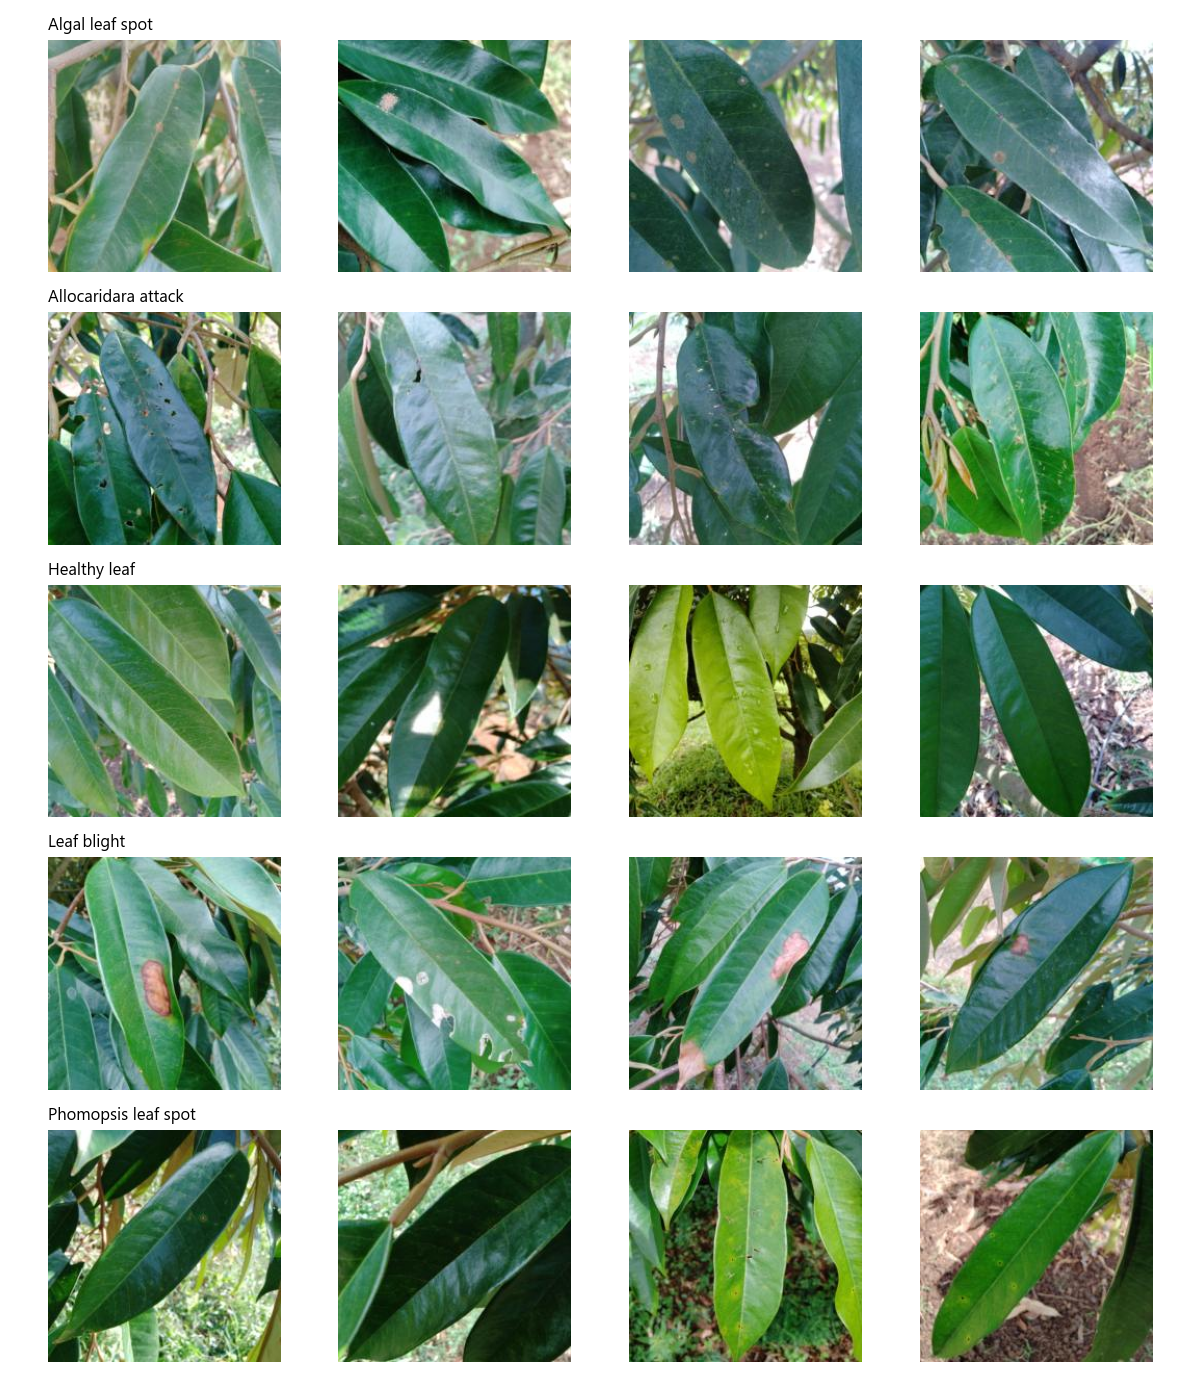

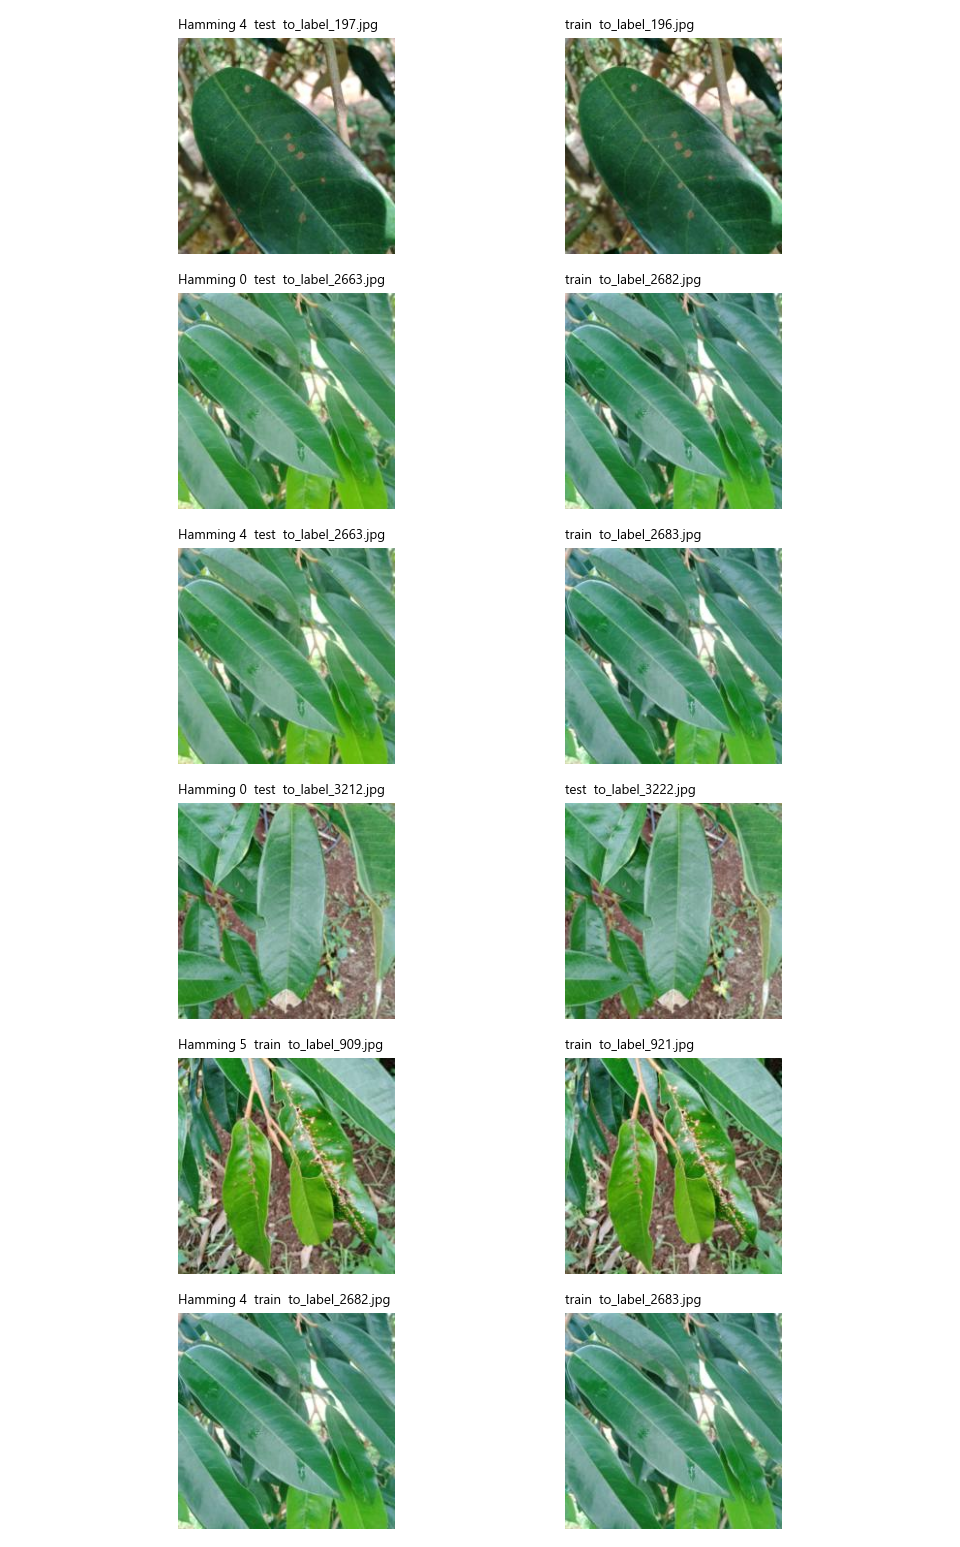

,path_a,path_b,split_a,split_b,class_a,hamming,relation,cross_split
0,DLD_FinalDataset_224_spit/test/ALGAL_LEAF_SPOT...,DLD_FinalDataset_224_spit/train/ALGAL_LEAF_SPO...,test,train,ALGAL_LEAF_SPOT,4,near,True
1,DLD_FinalDataset_224_spit/test/HEALTHY_LEAF/to...,DLD_FinalDataset_224_spit/train/HEALTHY_LEAF/t...,test,train,HEALTHY_LEAF,0,near,True
2,DLD_FinalDataset_224_spit/test/HEALTHY_LEAF/to...,DLD_FinalDataset_224_spit/train/HEALTHY_LEAF/t...,test,train,HEALTHY_LEAF,4,near,True
3,DLD_FinalDataset_224_spit/test/LEAF_BLIGHT/to_...,DLD_FinalDataset_224_spit/test/LEAF_BLIGHT/to_...,test,test,LEAF_BLIGHT,0,identical_file,False
4,DLD_FinalDataset_224_spit/train/ALLOCARIDARA_A...,DLD_FinalDataset_224_spit/train/ALLOCARIDARA_A...,train,train,ALLOCARIDARA_ATTACK,5,near,False
5,DLD_FinalDataset_224_spit/train/HEALTHY_LEAF/t...,DLD_FinalDataset_224_spit/train/HEALTHY_LEAF/t...,train,train,HEALTHY_LEAF,4,near,False


,max_hamming,pairs,images,cross_split_pairs,cross_class_pairs
0,0,2,4,1,0
1,5,6,9,3,0
2,8,10,16,4,3
3,10,39,68,15,20


In [4]:
display(Image(filename=str(REPORT_DIR / "figures" / "class_examples.png")))
display(Image(filename=str(REPORT_DIR / "figures" / "near_duplicate_pairs.png")))
pairs = pd.read_csv(REPORT_DIR / "tables" / "near_duplicate_pairs.csv")
display(pairs[["path_a", "path_b", "split_a", "split_b", "class_a", "hamming", "relation", "cross_split"]])
display(pd.read_csv(REPORT_DIR / "tables" / "near_duplicate_sensitivity.csv"))


## Kết luận cho bước sau

DurianLDD được giữ làm dữ liệu chính. Bước chia tập phải đọc `group_id` trong `image_inventory.csv` và không khóa split có sẵn, vì còn cảnh lá gần trùng nằm ở cả train và test. Báo cáo đầy đủ nằm ở `reports/data_quality/durian_ldd_data_quality_report.md`.
